# EBCC

EBCC (Error-Bounded Climate-data Compressor) [^1] combines JPEG2000 image compression with wavelet-based compression of residuals to achieve high compression ratios. EBCC can bound the pointwise absolute and range-relative error, though the error bound can sometimes be violated because of rounding errors. EBCC can compress two- or higher-dimensional 32 bit floating-point data, where the last two dimensions must be at least of size $32 \times 32$.

[1]: Huang, L., Fusco, L., Scheidl, F., Zibell, J., Sprenger, M. A., Schemm, S., & Hoefler, T. (2025). Error bounded compression for weather and climate applications. *arXiv*. Available from: [doi:10.48550/arxiv.2510.22265](https://doi.org/10.48550/arxiv.2510.22265).

In [1]:
from pathlib import Path

import numpy as np
import xarray as xr

In [2]:
data = Path("data")

In [3]:
import earthkit.plots

from quickplot import quickplot

## Importing the `Ebcc` compressor

In [4]:
from numcodecs_wasm_ebcc import Ebcc

In [5]:
?Ebcc

Init signature: Ebcc(base_cr, residual, _version='0.1.0', error=None)
Docstring:     
Codec providing compression using EBCC.

EBCC combines JPEG2000 compression with error-bounded residual compression.

Arrays that are higher-dimensional than 3D are encoded by compressing each
3D slice with EBCC independently. Specifically, the array's shape is
interpreted as `[.., depth, height, width]`. If you want to compress 3D
slices along three different axes, you can swizzle the array axes
beforehand.

Parameters
----------
base_cr : ...
    JPEG2000 positive base compression ratio
residual : ...
     - "jpeg2000-only": No residual compression - base JPEG2000 only
    
     - "absolute": Residual compression with absolute maximum error bound
    
     - "relative": Residual compression with relative error bound
_version : ..., optional, default = "0.1.0"
    The codec's encoding format version. Do not provide this parameter explicitly.
error : ..., optional
File:           ~/egu26-compression-s

## Targeting a specific compression ratio

EBCC can target a specific compression ratio using

```python
cr = 10  # x10 compression

Ebcc(base_cr=cr, residual="jpeg2000-only")
```

## Bounding the pointwise absolute error

EBCC can bound the absolute error using

```python
eb_abs = 1.0

base_cr = 50  # any base compression ratio, can be tuned

Ebcc(base_cr=base_cr, residual="absolute", error=eb_abs)
```

## Bounding the pointwise range-relative error

EBCC can bound the range-relative error using

```python
eb_range_rel = 0.01  # 1% of max(data) - min(data)

base_cr = 50  # any base compression ratio, can be tuned

Ebcc(base_cr=base_cr, residual="relative", error=eb_range_rel)
```

## Bounding the pointwise relative error

The easiest way to bound the pointwise relative error with EBCC is to transform the relative error bound into an absolute error bound [^3] using a metacompressor such as the `pw_rel_compressor_plugin` in LibPressio [^4] or the `numcodecs_pw_ratio.PointwiseRatioErrorBoundedCodec` port:

```python
from numcodecs_pw_ratio import PointwiseRatioErrorBoundedCodec
from numcodecs_wasm_zstd import Zstd

eb_rel = 0.01

base_cr = 50  # any base compression ratio, can be tuned

PointwiseRatioErrorBoundedCodec(
    # transform pointwise relative error bound into pointwise ratio error bound
    eb_ratio=1+eb_rel,
    # mark how the absolute error is configured
    eb_abs_marker="$eb_abs",
    # lossy compressor that will use an absolute error bound
    log_codec={ **Ebcc(base_cr=base_cr, residual="absolute", error=4.2).get_config(), "error": "$eb_abs" },
    # lossless compressor for compressing the data signs
    sign_codec=Zstd(level=3),
)
```

[3]: Liang, X., Di, S., Tao, D., Chen, Z., & Cappello, F. (2018). An Efficient Transformation Scheme for Lossy Data Compression with Point-Wise Relative Error Bound. *2018 IEEE International Conference on Cluster Computing (CLUSTER)*, 179–189. Available from: [doi:10.1109/cluster.2018.00036](https://doi.org/10.1109/cluster.2018.00036).

[4]: Underwood, R., Malvoso, V., Calhoun, J. C., Di, S., & Cappello, F. (2021). Productive and Performant Generic Lossy Data Compression with LibPressio. *2021 7th International Workshop on Data Analysis and Reduction for Big Scientific Data (DRBSD-7)*, 1–10. Available from: [doi:10.1109/drbsd754563.2021.00005](https://doi.org/10.1109/drbsd754563.2021.00005).

## Preserving Non-Finite Values

EBCC itself does not support preserving infinite and NaN values and raises an exception when compressing data that inludes non-finite values. A filter such as `numcodecs_replace.ReplaceFilterCodec` can be used to replace all non-finite values before compressing with EBCC, though this will not recreate these values during decompression:

```python
from numcodecs_combinators.stack import CodecStack
from numcodecs_replace import Replacement, ReplaceFilterCodec

eb_abs = 1.0

base_cr = 50  # any base compression ratio, can be tuned

CodecStack(
    ReplaceFilterCodec(replacements={ np.nan: "finite_mean", -np.inf: "finite_min", np.inf: "finite_max" }),
    Ebcc(base_cr=base_cr, residual="absolute", error=eb_abs),
)
```

## Example

In [6]:
# Load the data
ds = xr.open_dataset(
    data / "hplp" / "hplp_sfc_regridded_t_025deg_steps_228_240.nc",
    engine="netcdf4",
    decode_timedelta=True,
)
da = ds["2t"]

In [7]:
eb_range_rel = 0.01  # 1% of max(data) - min(data)

base_cr = 50  # any base compression ratio, can be tuned

codec = Ebcc(base_cr=base_cr, residual="relative", error=eb_range_rel)

In [8]:
# encode and decode the data
da_enc = codec.encode(da.values.astype(np.float32))
da_dec = da.copy(data=codec.decode(da_enc).astype(da.dtype))

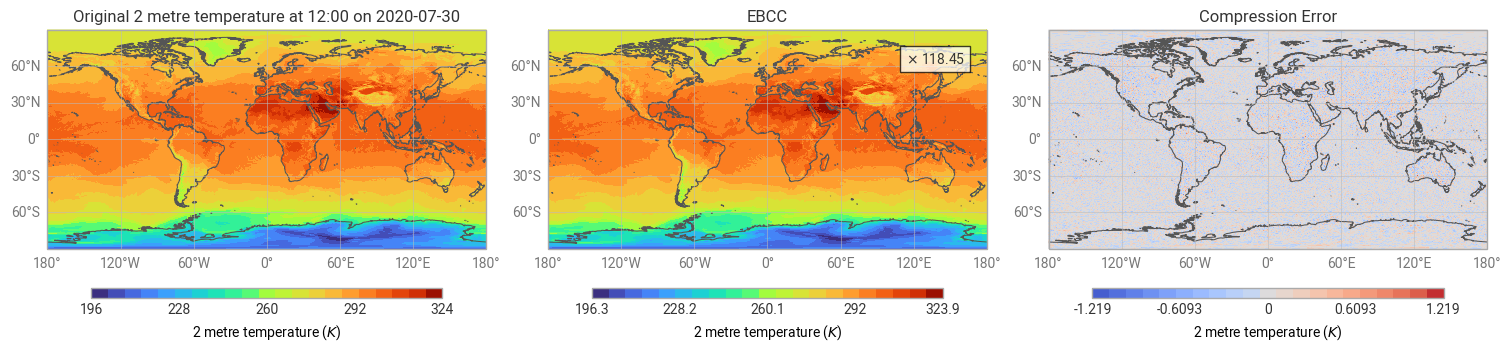

In [9]:
# plot a comparison figure
fig = earthkit.plots.Figure(
    size=(15, 4),
    rows=1,
    columns=3,
)

quickplot(da, fig.add_map(0, 0), title="Original {default_title}")
quickplot(
    da_dec, fig.add_map(0, 1), title="EBCC", cr=da.nbytes / np.array(da_enc).nbytes
)
quickplot(da_dec - da, fig.add_map(0, 2), error=True, title="Compression Error")

fig.show()